# Analysis

Train the various algorithms and show your results. 

You must plot the reward obtained by your agent per step and the total regret accumulated so far.

This one is an open ended assignment, so feel free to play around. Extra credit for more beautiful plots (you can check out Seaborn). 

In [1]:
import warnings ; warnings.filterwarnings('ignore')
from pprint import pprint
from itertools import cycle

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab 
# import seaborn as sns
# import sys
# import os
# module_path = os.path.abspath(os.path.join('.'))
# if module_path not in sys.path:
#     sys.path.append(module_path)

from bandits import Bandit
from agents import *

np.random.seed(122)

%matplotlib inline

In [3]:
print("plt.style.available: ", plt.style.available)

plt.style.available:  ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [4]:
plt.style.use('fivethirtyeight')
params = {
    'figure.figsize': (15, 8),
    'font.size': 24,
    'legend.fontsize': 20,
    'axes.titlesize': 28,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20
}
pylab.rcParams.update(params)
np.set_printoptions(suppress=True)

In [5]:
# Create Bandits: (5-armed bandits)
banditBern = Bandit(n=5, type='Bernoulli')
banditGauss = Bandit(n=5, type='Gaussian')

In [6]:
# checking the bandits functions
print(banditBern.getN())
print(banditGauss.getN())

5
5


In [7]:
print(banditGauss.means)
print(banditGauss.optimal)

[28.51406467 33.14352649  8.94456017  9.44529263 12.29511496]
33.143526488136835


In [8]:
# create agents
agentsBern = [GreedyAgent(banditBern), epsGreedyAgent(banditBern,epsilon=0.07), UCBAAgent(banditBern), GradientBanditAgent(banditBern), ThompsonSamplerAgent(banditBern,alpha=1,beta=1), exp_dec_epsGreedyAgent(banditBern,1.0,0.0,0.1), exp_dec_epsGreedyAgent(banditBern,1.0,0.0,0.3)]

agentsGauss = [GreedyAgent(banditGauss), epsGreedyAgent(banditGauss, epsilon=0.07), UCBAAgent(banditGauss), GradientBanditAgent(banditGauss), ThompsonSamplerAgent(banditGauss,alpha=1,beta=1),exp_dec_epsGreedyAgent(banditGauss,1.0,0.0,0.1), exp_dec_epsGreedyAgent(banditGauss,1.0,0.0,0.3)]


In [9]:
nameOfAgent=['Greedy', 
             'Epsilon Greedy 0.07', 
             'UCBA', 'Gradient Bandit', 
             'Thompson Sampler 1 1', 
             'exp dec eps greedy 1.0,0.0,0.1', 
             'exp dec eps greedy 1.0,0.0,0.3']

In [10]:
# agentsBern[0] for demo
i=4
agent=agentsBern[i]
n_episodes = 1000
Qe=np.empty((n_episodes, banditBern.getN()), dtype=np.float64)
returns = np.empty(n_episodes, dtype=np.float64)
actions = np.empty(n_episodes, dtype=int)

for e in range(n_episodes):
    action=agent.action() if i != 2 else agent.action(e)
    reward=banditBern.choose(action)
    agent.update(action, reward)
    Q, N = agent.getQN()
    Qe[e]=Q
    returns[e] = reward
    actions[e]=action


In [11]:
name=nameOfAgent[i]
print(name)
print(f'Probability of Rewards in: {banditBern.probs}')
print(f'Optimal Rewards: {banditBern.optimal}')
print('_'*50)

Thompson Sampler 1 1
Probability of Rewards in: [0.15699184 0.70221004 0.26147827 0.45171291 0.40806526]
Optimal Rewards: 0.7022100424924458
__________________________________________________


In [12]:
results={}
true_Q=banditBern.probs
opt_V=banditBern.optimal
name,Re,Qe,Ae=name,returns,Qe,actions
Ae=np.expand_dims(Ae,-1)
episode_mean_rew = np.cumsum(Re) / (np.arange(len(Re)) + 1)
Q_selected = np.take_along_axis(
                    np.tile(true_Q, Ae.shape), Ae, axis=1).squeeze()
regret = opt_V - Q_selected
cum_regret = np.cumsum(regret)
if name not in results.keys(): results[name] = {}
if 'Re' not in results[name].keys(): results[name]['Re'] = []
if 'Qe' not in results[name].keys(): results[name]['Qe'] = []
if 'Ae' not in results[name].keys(): results[name]['Ae'] = []
if 'cum_regret' not in results[name].keys(): 
                    results[name]['cum_regret'] = []
if 'episode_mean_rew' not in results[name].keys(): 
                results[name]['episode_mean_rew'] = []

results[name]['Re'].append(Re)
results[name]['Qe'].append(Qe)
results[name]['Ae'].append(Ae)
results[name]['cum_regret'].append(cum_regret)
results[name]['episode_mean_rew'].append(episode_mean_rew)

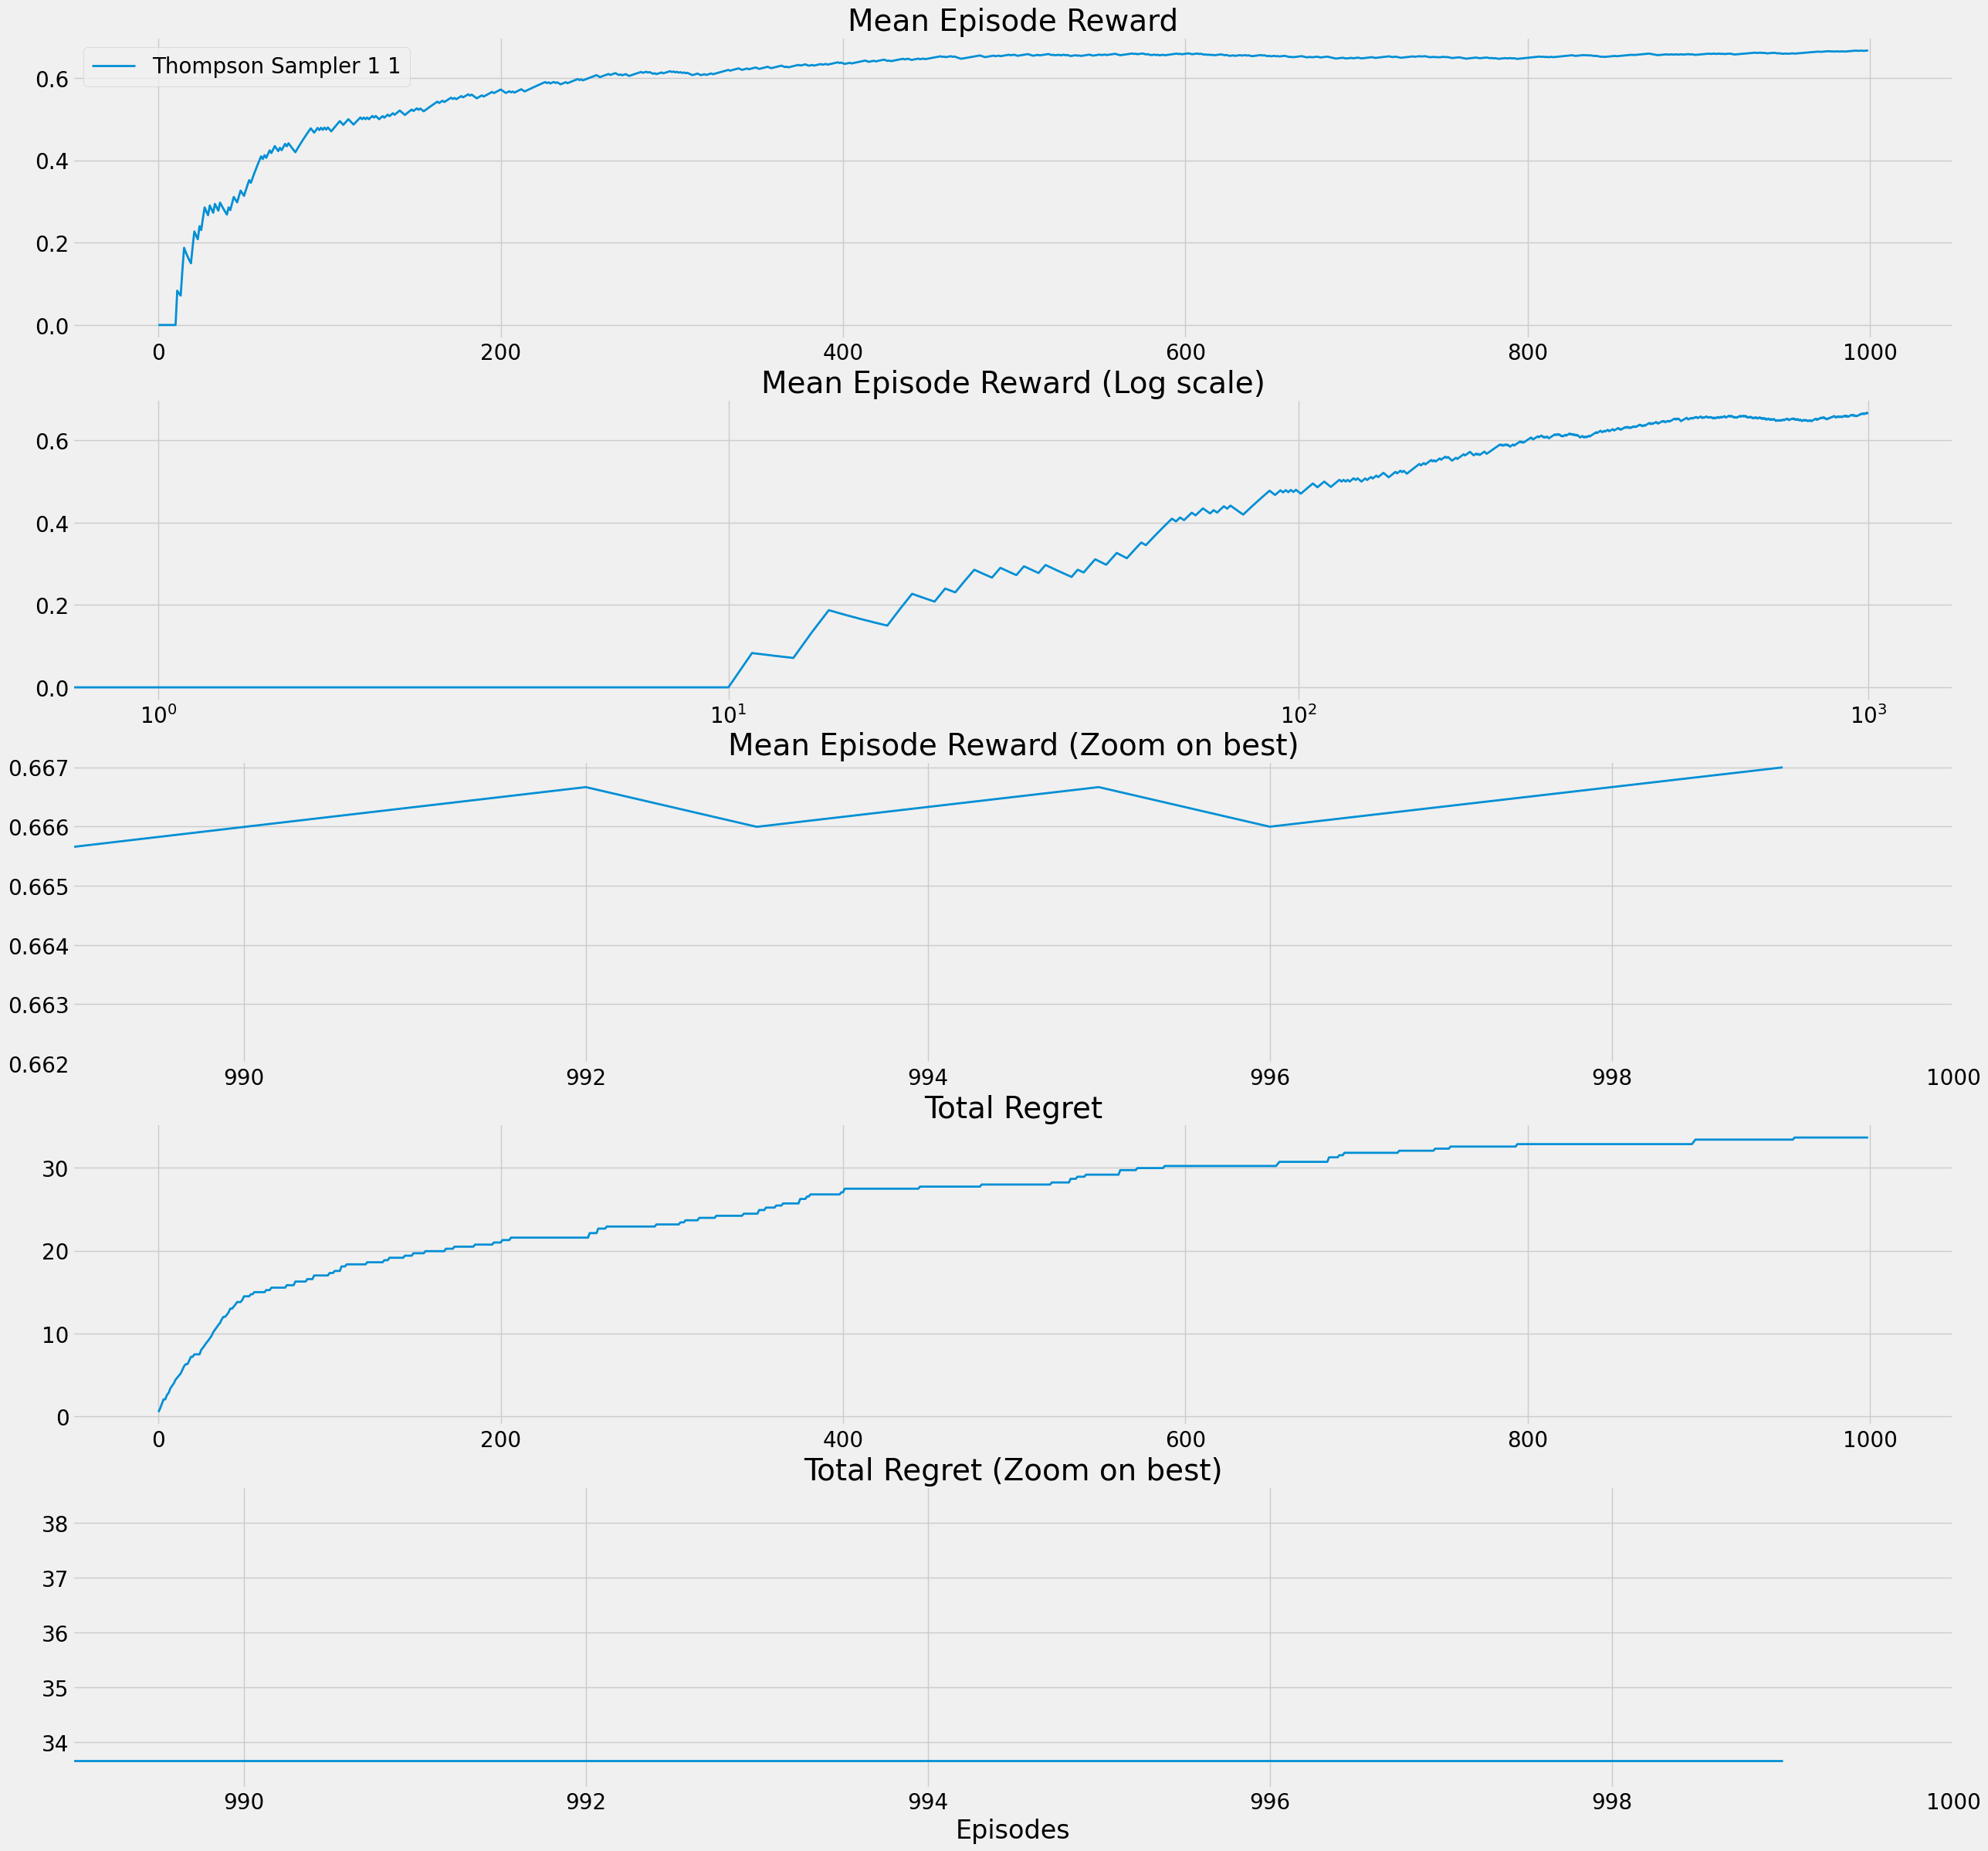

In [14]:
fig, axs = plt.subplots(5, 1, figsize=(28, 28), sharey=False, sharex=False)

lines = ["-","--",":","-."]
linecycler = cycle(lines)
min_reg, max_ret = float('inf'), float('-inf')
for label, result in results.items():
    color = next(linecycler)

    # reward
    episode_mean_rew = np.array(result['episode_mean_rew'])
    mean_episode_mean_rew = np.mean(episode_mean_rew, axis=0)

    axs[0].plot(mean_episode_mean_rew, color, linewidth=2, label=label)

    axs[1].plot(mean_episode_mean_rew, color, linewidth=2, label=label)
    axs[1].set_xscale('log')
    
    axs[2].plot(mean_episode_mean_rew, color, linewidth=2, label=label)
    if max_ret < mean_episode_mean_rew[-1]: max_ret = mean_episode_mean_rew[-1]
    axs[2].axis((mean_episode_mean_rew.shape[0]*0.989,
                 mean_episode_mean_rew.shape[0],
                 max_ret-0.005,
                 max_ret+0.0001))

    # regret
    cum_regret = np.array(result['cum_regret'])
    mean_cum_regret = np.mean(cum_regret, axis=0)

    axs[3].plot(mean_cum_regret, color, linewidth=2, label=label)
    
    axs[4].plot(mean_cum_regret, color, linewidth=2, label=label)
    if min_reg > mean_cum_regret[-1]: min_reg = mean_cum_regret[-1]
    plt.axis((mean_cum_regret.shape[0]*0.989,
              mean_cum_regret.shape[0],
              min_reg-0.5,
              min_reg+5))

    # config plot
    axs[0].set_title('Mean Episode Reward')
    axs[1].set_title('Mean Episode Reward (Log scale)')
    axs[2].set_title('Mean Episode Reward (Zoom on best)')
    axs[3].set_title('Total Regret')
    axs[4].set_title('Total Regret (Zoom on best)')
    plt.xlabel('Episodes')
    axs[0].legend(loc='upper left')

plt.show()

# Plotting the Bernoulli Bandit

Probability of Rewards: [0.15699184 0.70221004 0.26147827 0.45171291 0.40806526]
Optimal Rewards: 0.7022100424924458
__________________________________________________


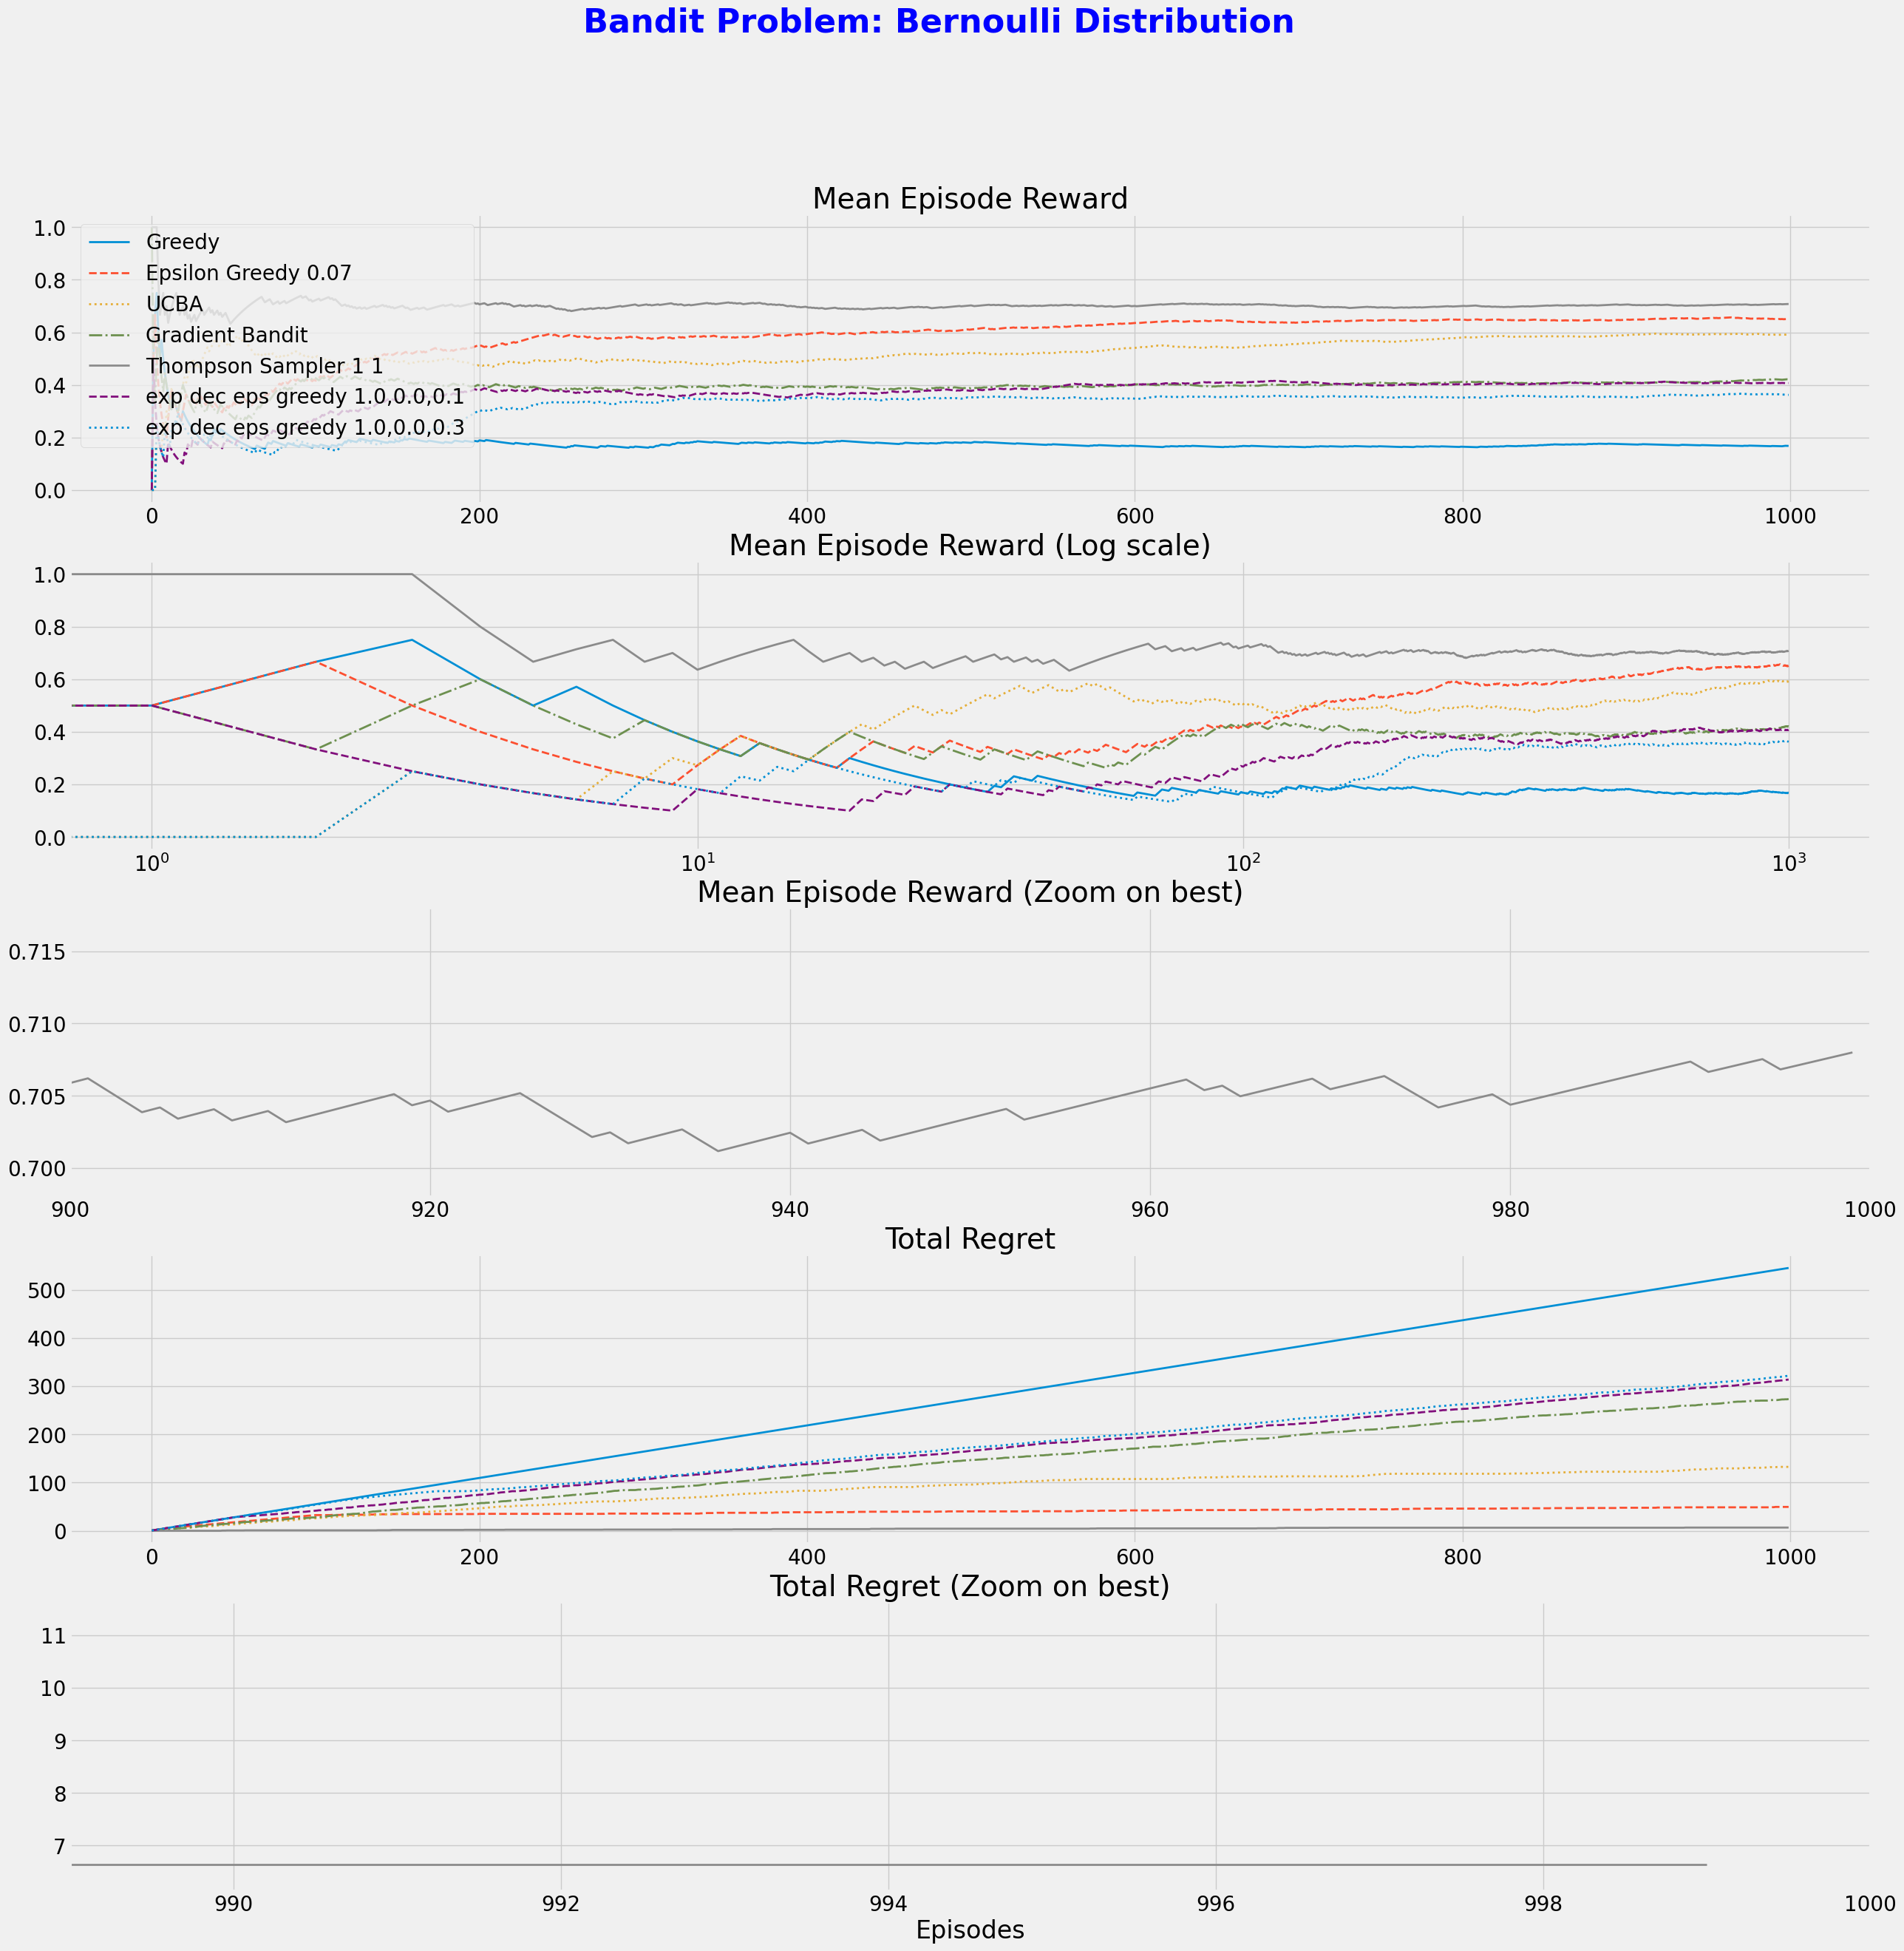

In [15]:
results={}
print(f'Probability of Rewards: {banditBern.probs}')
print(f'Optimal Rewards: {banditBern.optimal}')
print('_'*50)
for i in range(len(agentsBern)):
    agent=agentsBern[i]
    n_episodes = 1000
    Qe=np.empty((n_episodes, banditBern.getN()), dtype=np.float64)
    returns = np.empty(n_episodes, dtype=np.float64)
    actions = np.empty(n_episodes, dtype=int)

    for e in range(n_episodes):
        try:
            action=agent.action()
        except:
            action=agent.action(e)
        reward=banditBern.choose(action)
        agent.update(action, reward)
        Q, N = agent.getQN()
        Qe[e]=Q
        returns[e] = reward
        actions[e]=action
    name=nameOfAgent[i]

    true_Q=banditBern.probs
    opt_V=banditBern.optimal
    name,Re,Qe,Ae=name,returns,Qe,actions
    Ae=np.expand_dims(Ae,-1)
    episode_mean_rew = np.cumsum(Re) / (np.arange(len(Re)) + 1)
    Q_selected = np.take_along_axis(
                        np.tile(true_Q, Ae.shape), Ae, axis=1).squeeze()
    regret = opt_V - Q_selected
    cum_regret = np.cumsum(regret)
    if name not in results.keys(): results[name] = {}
    if 'Re' not in results[name].keys(): results[name]['Re'] = []
    if 'Qe' not in results[name].keys(): results[name]['Qe'] = []
    if 'Ae' not in results[name].keys(): results[name]['Ae'] = []
    if 'cum_regret' not in results[name].keys(): 
                        results[name]['cum_regret'] = []
    if 'episode_mean_rew' not in results[name].keys(): 
                    results[name]['episode_mean_rew'] = []

    results[name]['Re'].append(Re)
    results[name]['Qe'].append(Qe)
    results[name]['Ae'].append(Ae)
    results[name]['cum_regret'].append(cum_regret)
    results[name]['episode_mean_rew'].append(episode_mean_rew)


fig, axs = plt.subplots(5, 1, figsize=(28, 28), sharey=False, sharex=False)

lines = ["-","--",":","-."]
linecycler = cycle(lines)
min_reg, max_ret = float('inf'), float('-inf')
for label, result in results.items():
    color = next(linecycler)

    # reward
    episode_mean_rew = np.array(result['episode_mean_rew'])
    mean_episode_mean_rew = np.mean(episode_mean_rew, axis=0)

    axs[0].plot(mean_episode_mean_rew, color, linewidth=2, label=label)

    axs[1].plot(mean_episode_mean_rew, color, linewidth=2, label=label)
    axs[1].set_xscale('log')
    
    axs[2].plot(mean_episode_mean_rew, color, linewidth=2, label=label)
    if max_ret < mean_episode_mean_rew[-1]: max_ret = mean_episode_mean_rew[-1]
    # Adjust the x-axis to start from a smaller fraction of the total episodes, for broader view
    x_start_fraction = 0.9  # Example: Start from 90% of episodes for a broader view
    y_padding = 0.01  # Add some padding to the y-axis range for visibility

    # Calculate new axis limits
    x_start = mean_episode_mean_rew.shape[0] * x_start_fraction
    x_end = mean_episode_mean_rew.shape[0]
    y_start = max_ret - y_padding
    y_end = max_ret + y_padding

    # Apply the new axis limits
    axs[2].axis((x_start, x_end, y_start, y_end))

    # regret
    cum_regret = np.array(result['cum_regret'])
    mean_cum_regret = np.mean(cum_regret, axis=0)

    axs[3].plot(mean_cum_regret, color, linewidth=2, label=label)
    
    axs[4].plot(mean_cum_regret, color, linewidth=2, label=label)
    if min_reg > mean_cum_regret[-1]: min_reg = mean_cum_regret[-1]
    plt.axis((mean_cum_regret.shape[0]*0.989,
            mean_cum_regret.shape[0],
            min_reg-0.5,
            min_reg+5))

    # config plot
    axs[0].set_title('Mean Episode Reward')
    axs[1].set_title('Mean Episode Reward (Log scale)')
    axs[2].set_title('Mean Episode Reward (Zoom on best)')
    axs[3].set_title('Total Regret')
    axs[4].set_title('Total Regret (Zoom on best)')
    plt.xlabel('Episodes')
    axs[0].legend(loc='upper left')

fig.suptitle('Bandit Problem: Bernoulli Distribution', fontsize=32, fontweight='bold',color='blue')
plt.savefig('bandit_bernoulli.png')
plt.show()

# Plotting the Gaussian Bandit

Probability of Rewards: [28.51406467 33.14352649  8.94456017  9.44529263 12.29511496]
Optimal Rewards: 33.143526488136835
__________________________________________________


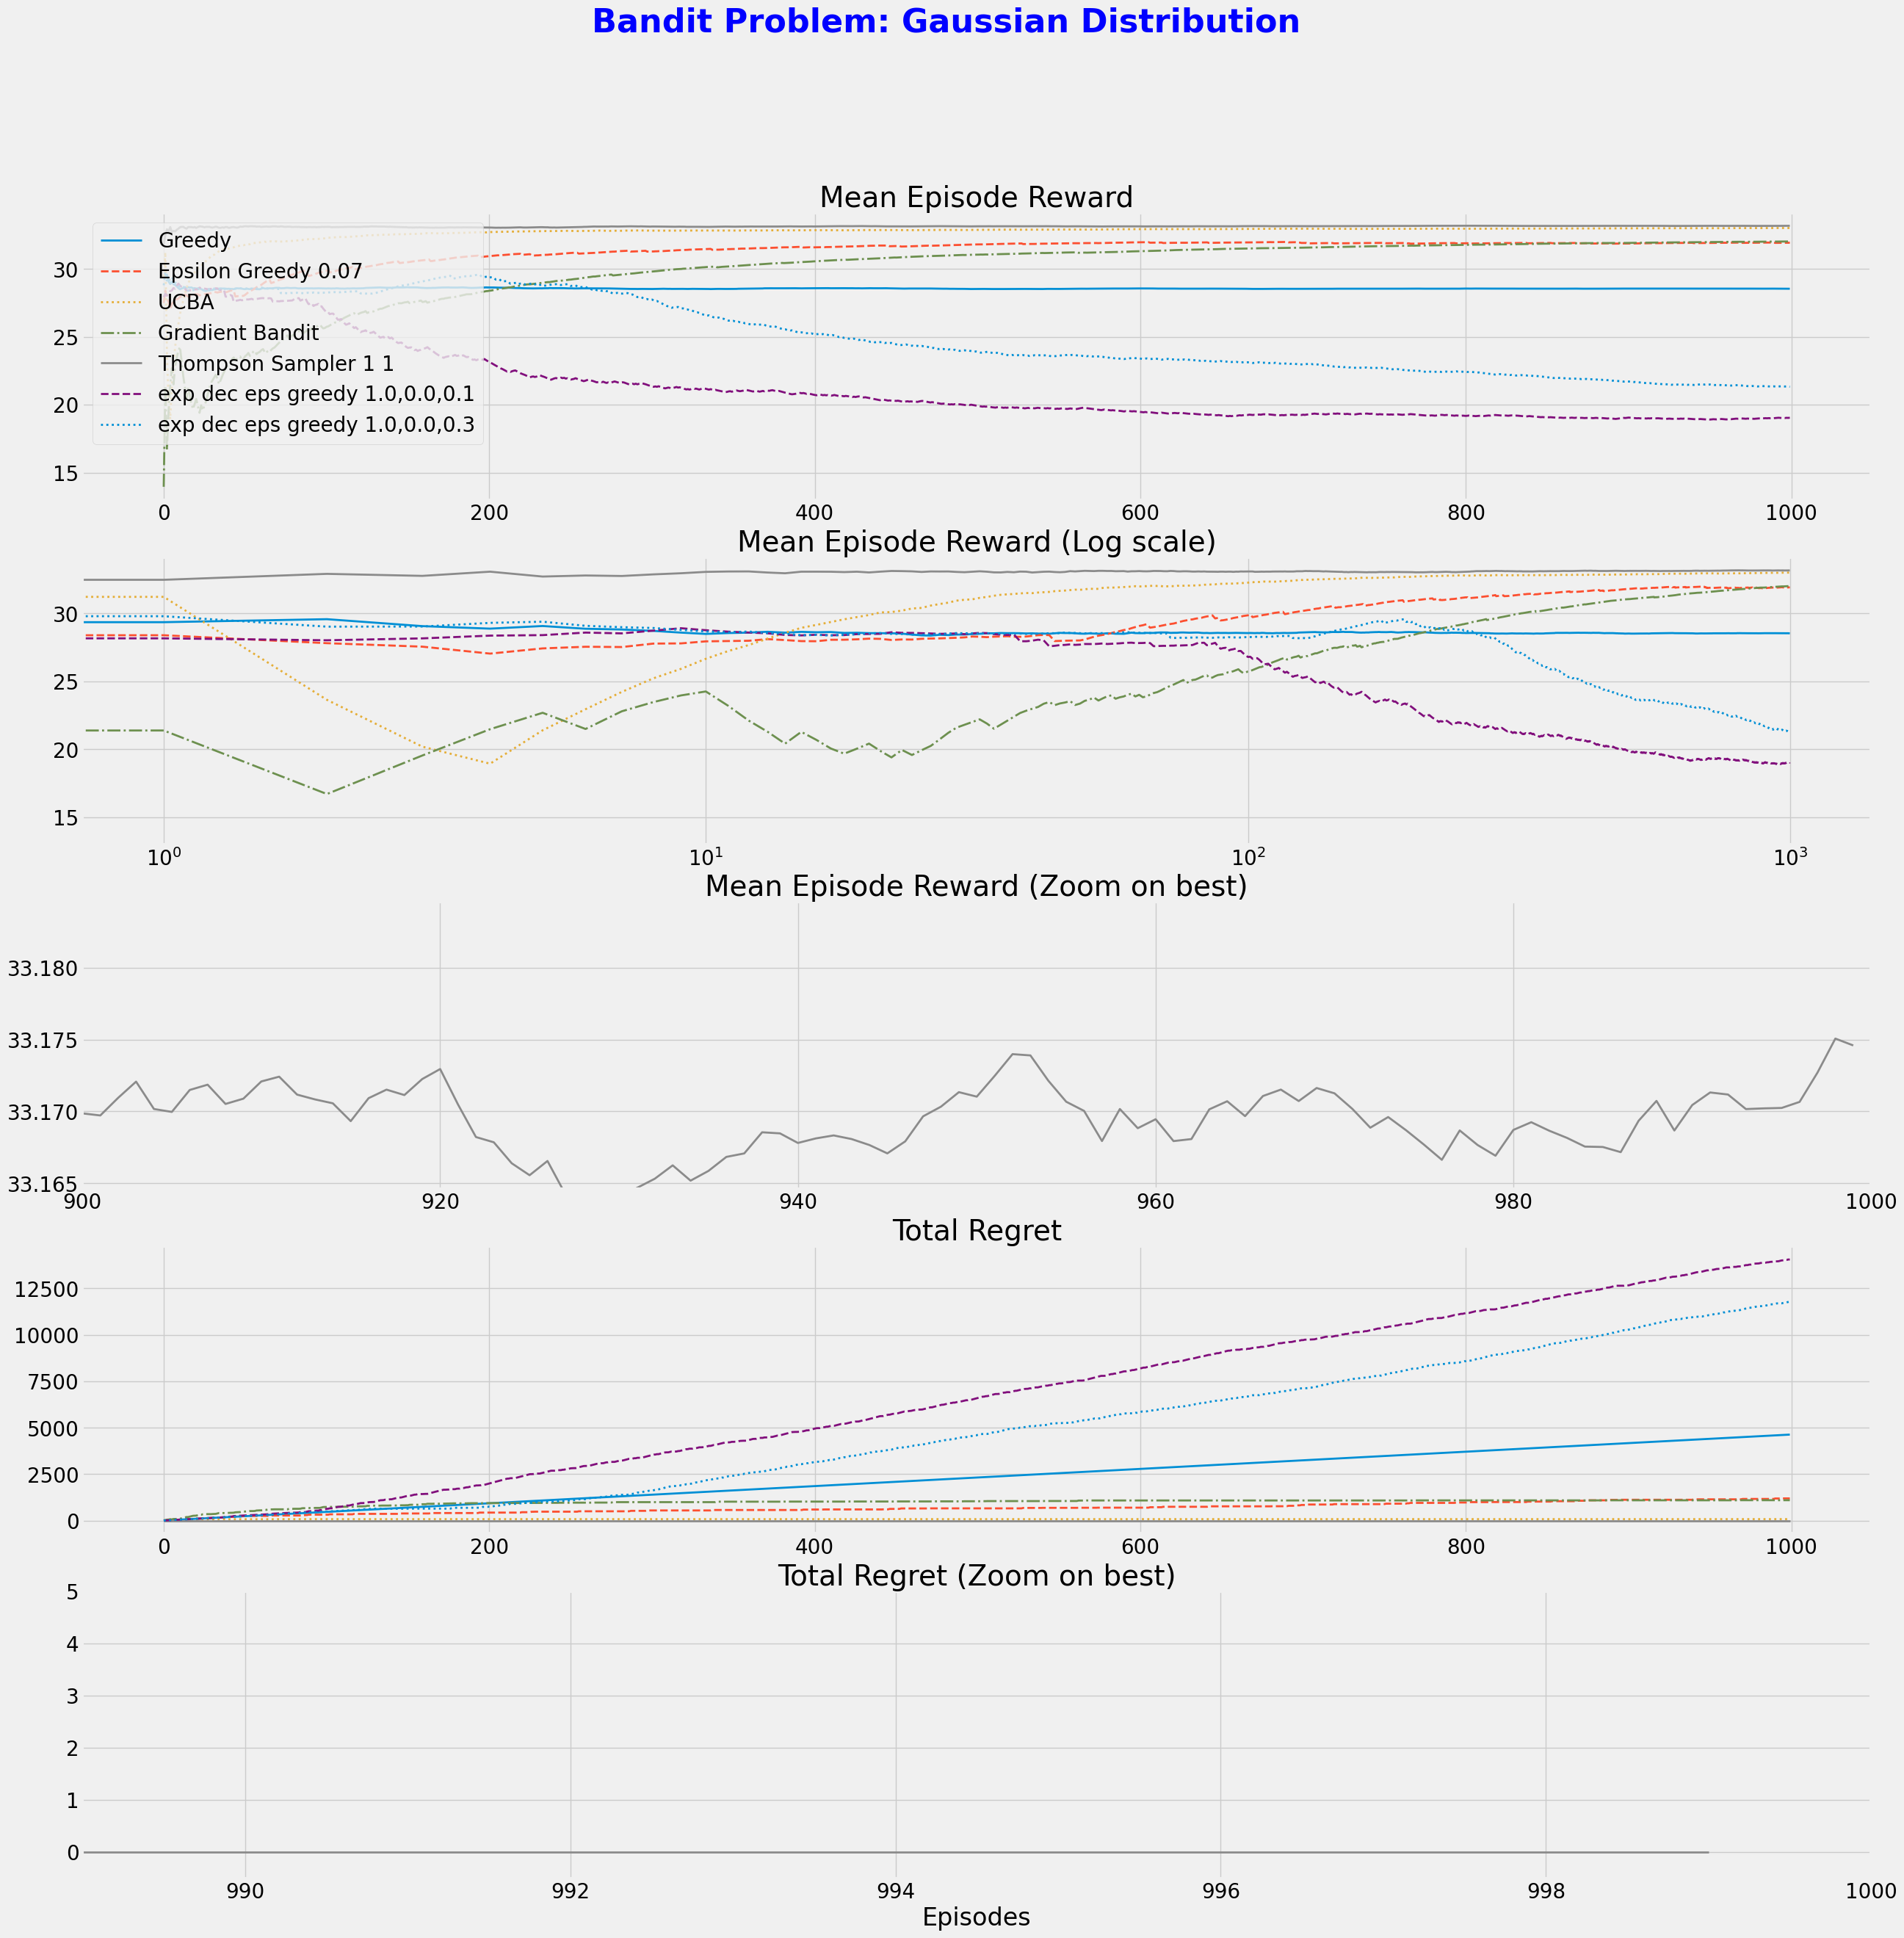

In [16]:
results={}
print(f'Probability of Rewards: {banditGauss.means}')
print(f'Optimal Rewards: {banditGauss.optimal}')
print('_'*50)
for i in range(len(agentsGauss)):
    agent=agentsGauss[i]
    n_episodes = 1000
    Qe=np.empty((n_episodes, banditGauss.getN()), dtype=np.float64)
    returns = np.empty(n_episodes, dtype=np.float64)
    actions = np.empty(n_episodes, dtype=int)

    for e in range(n_episodes):
        try:
            action=agent.action()
        except:
            action=agent.action(e)
        reward=banditGauss.choose(action)
        agent.update(action, reward)
        Q, N = agent.getQN()
        Qe[e]=Q
        returns[e] = reward
        actions[e]=action
    name=nameOfAgent[i]

    true_Q=banditGauss.means
    opt_V=banditGauss.optimal
    name,Re,Qe,Ae=name,returns,Qe,actions
    Ae=np.expand_dims(Ae,-1)
    episode_mean_rew = np.cumsum(Re) / (np.arange(len(Re)) + 1)
    Q_selected = np.take_along_axis(
                        np.tile(true_Q, Ae.shape), Ae, axis=1).squeeze()
    regret = opt_V - Q_selected
    cum_regret = np.cumsum(regret)
    if name not in results.keys(): results[name] = {}
    if 'Re' not in results[name].keys(): results[name]['Re'] = []
    if 'Qe' not in results[name].keys(): results[name]['Qe'] = []
    if 'Ae' not in results[name].keys(): results[name]['Ae'] = []
    if 'cum_regret' not in results[name].keys(): 
                        results[name]['cum_regret'] = []
    if 'episode_mean_rew' not in results[name].keys(): 
                    results[name]['episode_mean_rew'] = []

    results[name]['Re'].append(Re)
    results[name]['Qe'].append(Qe)
    results[name]['Ae'].append(Ae)
    results[name]['cum_regret'].append(cum_regret)
    results[name]['episode_mean_rew'].append(episode_mean_rew)


fig, axs = plt.subplots(5, 1, figsize=(28, 28), sharey=False, sharex=False)

lines = ["-","--",":","-."]
linecycler = cycle(lines)
min_reg, max_ret = float('inf'), float('-inf')
for label, result in results.items():
    color = next(linecycler)

    # reward
    episode_mean_rew = np.array(result['episode_mean_rew'])
    mean_episode_mean_rew = np.mean(episode_mean_rew, axis=0)

    axs[0].plot(mean_episode_mean_rew, color, linewidth=2, label=label)

    axs[1].plot(mean_episode_mean_rew, color, linewidth=2, label=label)
    axs[1].set_xscale('log')
    
    axs[2].plot(mean_episode_mean_rew, color, linewidth=2, label=label)
    if max_ret < mean_episode_mean_rew[-1]: max_ret = mean_episode_mean_rew[-1]
    # Adjust the x-axis to start from a smaller fraction of the total episodes, for broader view
    x_start_fraction = 0.9  # Example: Start from 90% of episodes for a broader view
    y_padding = 0.01  # Add some padding to the y-axis range for visibility

    # Calculate new axis limits
    x_start = mean_episode_mean_rew.shape[0] * x_start_fraction
    x_end = mean_episode_mean_rew.shape[0]
    y_start = max_ret - y_padding
    y_end = max_ret + y_padding

    # Apply the new axis limits
    axs[2].axis((x_start, x_end, y_start, y_end))

    # regret
    cum_regret = np.array(result['cum_regret'])
    mean_cum_regret = np.mean(cum_regret, axis=0)

    axs[3].plot(mean_cum_regret, color, linewidth=2, label=label)
    
    axs[4].plot(mean_cum_regret, color, linewidth=2, label=label)
    if min_reg > mean_cum_regret[-1]: min_reg = mean_cum_regret[-1]
    plt.axis((mean_cum_regret.shape[0]*0.989,
            mean_cum_regret.shape[0],
            min_reg-0.5,
            min_reg+5))

    # config plot
    axs[0].set_title('Mean Episode Reward')
    axs[1].set_title('Mean Episode Reward (Log scale)')
    axs[2].set_title('Mean Episode Reward (Zoom on best)')
    axs[3].set_title('Total Regret')
    axs[4].set_title('Total Regret (Zoom on best)')
    plt.xlabel('Episodes')
    axs[0].legend(loc='upper left')
    
fig.suptitle('Bandit Problem: Gaussian Distribution', fontsize=32, fontweight='bold',color='blue')
plt.savefig('bandit_gaussian.png')
plt.show()